# Task 9.1 P
### Name: Nay Tun
### Student Id: 225110052

In [119]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedShuffleSplit, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


#

# 1. Download the NF1 disease dataset and print the dimension of the dataset, fill in the missing values with an appropriate method. 

In [87]:
df = pd.read_excel("https://github.com/nay-deakin/sit720-data/raw/refs/heads/main/dataset-uci.xlsx", sheet_name="Dataset")
df = df.drop('Unnamed: 0', axis=1)
df.head()

,Case Type,Tumour Case,Age of Mother,Age of Father,Age at First Diagnosis,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
0,0,1,30.0,31.0,5.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0,1,22.0,29.0,7.0,1,1,0,0,1,0,0,0,0,0,0,0,0,1
2,1,1,28.0,26.0,9.0,1,1,0,0,1,0,0,1,0,0,0,0,0,1
3,0,1,30.0,34.0,9.0,1,1,0,1,0,1,0,0,0,0,0,0,0,1
4,0,1,27.0,34.0,1.0,1,1,1,0,0,0,1,0,0,0,0,0,0,1


### Look at missing

In [88]:
df.isna().sum()

Case Type                    0
Tumour Case                  0
Age of Mother               35
Age of Father               34
Age at First Diagnosis       4
Café au lait (CLS)           0
Axillary Freckles            0
Inguinal Freckles            0
Lisch Nodules                0
Dermal Neurofibromins        0
Plexiform Neurofibromins     0
Optic Glioma                 0
Skeletal Dysplasia           0
Learning Disability          0
Hypertension                 0
Astrocytoma                  0
Hamartoma                    0
Scoliosis                    0
Other Symptoms               0
dtype: int64

### Define numerical cols and categorical columns (no OHE required)

In [89]:
target_cols = ['Case Type']
numerical_cols = ['Age of Mother', 'Age of Father', 'Age at First Diagnosis']
categorical_cols = [col for col in df.columns if col not in target_cols + numerical_cols]

### Missing cols are numerical and we will check if they are a normal distribution

In [90]:
from scipy import stats
for col in numerical_cols:
    stat, p_value = stats.shapiro(df.loc[df[col].notna(),col])
    print (f"{col} - Stat: {stat}, p-value: {p_value}")

Age of Mother - Stat: 0.9776055709418295, p-value: 0.0003951314376203481
Age of Father - Stat: 0.9386319298676379, p-value: 5.469854954032168e-09
Age at First Diagnosis - Stat: 0.8077494423495201, p-value: 2.6394499326387616e-18


### None of these columns are normal so we will use Median

### Setup the pipeline and preprecessor

In [91]:
def fill_numerical(X, cols):
    X = X.copy()
    for col in cols:
        X[col] = X[col].fillna(X[col].median())
    return X

null_imputer_numerical = FunctionTransformer(
    fill_numerical,
    kw_args = {'cols': numerical_cols},
    validate = False,
    feature_names_out = 'one-to-one'
)

numeric_pipeline = Pipeline([
    ('fill_numerical', null_imputer_numerical)
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numerical_cols),
    ('categorical', 'passthrough', categorical_cols),
])


### Check the class ratios

In [92]:
df.groupby('Case Type')['Case Type'].count()/df['Case Type'].count()

Case Type
0    0.543919
1    0.456081
Name: Case Type, dtype: float64

### 54/45 so fairly balanced

#

# 2. Split the data set into training and test set (8:2), train a full decision tree to predict the tumour case, report the model performance.

In [93]:
X = df.drop(columns = target_cols)
y = df[target_cols[0]]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [95]:
X_preproc = preprocessor.fit_transform(X_train,y_train)
x_features = preprocessor.get_feature_names_out()
X_preproc_df = pd.DataFrame(X_preproc, columns = x_features)
X_preproc_df['target'] = y_train.values
X_preproc_df.head()


,numeric__Age of Mother,numeric__Age of Father,numeric__Age at First Diagnosis,categorical__Tumour Case,categorical__Café au lait (CLS),categorical__Axillary Freckles,categorical__Inguinal Freckles,categorical__Lisch Nodules,categorical__Dermal Neurofibromins,categorical__Plexiform Neurofibromins,categorical__Optic Glioma,categorical__Skeletal Dysplasia,categorical__Learning Disability,categorical__Hypertension,categorical__Astrocytoma,categorical__Hamartoma,categorical__Scoliosis,categorical__Other Symptoms,target
0,22.0,26.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,19.0,25.0,16.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,22.0,23.0,8.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
3,21.0,22.0,9.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1
4,32.0,35.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


### Declare the model

In [96]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=1)),
])

In [97]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.58      0.54        33
           1       0.39      0.33      0.36        27

    accuracy                           0.47        60
   macro avg       0.45      0.45      0.45        60
weighted avg       0.46      0.47      0.46        60

[[19 14]
 [18  9]]


# DT Grid search with stratified Kfold

In [98]:

do_grid_search = True
if do_grid_search:
    param_grid = {
        'classifier__max_depth': [3, 5, 10, 15, 20, 25],
        'classifier__min_samples_split': [2, 10, 20, 50],
        'classifier__min_samples_leaf': [50, 60, 70, 80, 90, 100, 110, 120],
        'classifier__criterion': ['gini', 'entropy'],
        'classifier__max_features': [None, 'sqrt', 'log2'],
        'classifier__class_weight': ['balanced', {0:0.55, 1:0.45}, {0:0.50, 1:0.50}, {0:0.45, 1:0.55}],
    }
    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)
    print(f"Best params: {grid_search.best_params_}")


Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__max_features': None, 'classifier__min_samples_leaf': 80, 'classifier__min_samples_split': 2}


In [99]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=1
            , class_weight=grid_search.best_params_['classifier__class_weight']
            , criterion=grid_search.best_params_['classifier__criterion']
            , max_depth=grid_search.best_params_['classifier__max_depth']
            , max_features=grid_search.best_params_['classifier__max_features']
            , min_samples_leaf=grid_search.best_params_['classifier__min_samples_leaf']
            , min_samples_split=grid_search.best_params_['classifier__min_samples_split']

        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.33      0.43        33
           1       0.48      0.74      0.58        27

    accuracy                           0.52        60
   macro avg       0.54      0.54      0.51        60
weighted avg       0.55      0.52      0.50        60

[[11 22]
 [ 7 20]]


### Tuning it, does make the model slightly better but it doesn't seem like decision tree model is the right model for this dataset.

### Confusion Matrix

||Predicted 0|Predicted 1|
|---------|--------|--------|
|Actual 0|11|22|
|Actual 1|7|20|

### The model is biased towards class 1.  It got 20 right and 7 wrong for Class 1.  but for class 0 it is predicting 22 test data to have tumors while their actual is no tumor.

### Accuracy is 52% F1 score, which is slightly better than tossing a coin

# 

# 3. From question 2 visualize the decision tree, what is the root feature? How much does gini or entropy change after splitting with the root feature ? 

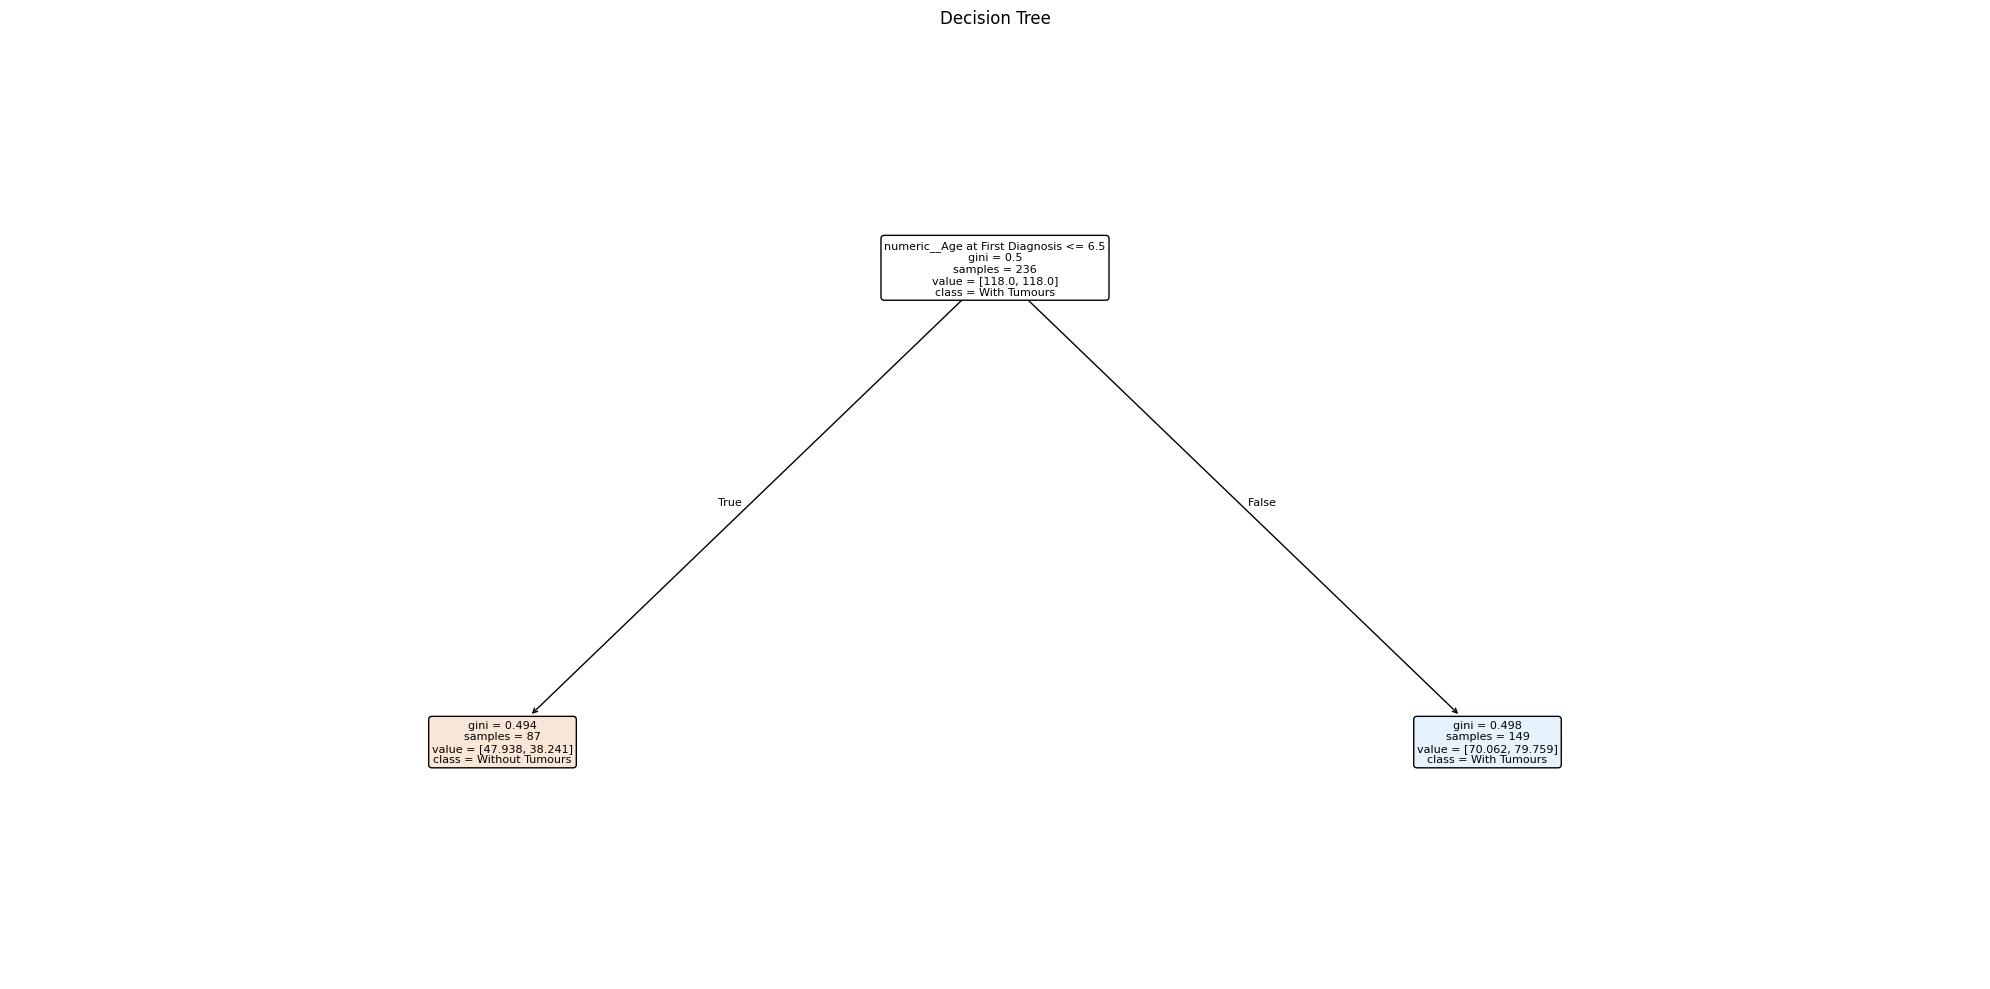

In [100]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    model.named_steps['classifier'],
    feature_names=x_features,
    class_names=['Without Tumours', 'With Tumours'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth= 10
)
plt.title('Decision Tree')
plt.tight_layout()
plt.show()

### Root feature is Age at First Diagnosis <= 6.5
### Root gini = 0.5
### 2 Child nodes are create the gini values are 0.494 and 0.498 and 87 and 149 sample respectively
### Weighted gini - (87/236 * 0.494) + (149/236 * 0.498)
### 0.182 + 0.314 = 0.496
### Gini change = 0.5 - 0.496 = 0.004

#



# 4. Vary the depth of the decision tree, plot the model performance change versus the size of the tree, indicate what is the best size of the tree and explain the bias-variance trade-off  in this context.

In [101]:
depths = param_grid['classifier__max_depth']
train_scores = []
test_scores = []
for depth in depths:
    dt = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=1))
    ])
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

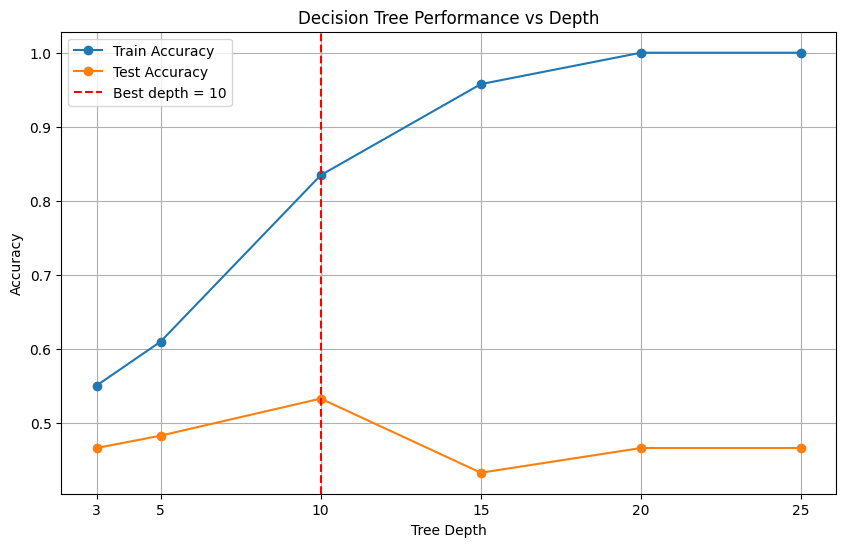

In [102]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance vs Depth')
plt.legend()
plt.xticks(depths)
plt.grid(True)

# Mark best depth
best_depth = depths[test_scores.index(max(test_scores))]
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.legend()
plt.show()

In [103]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=1
            #, class_weight=grid_search.best_params_['classifier__class_weight']
            #, criterion=grid_search.best_params_['classifier__criterion']
            , max_depth=10
            #, max_features=grid_search.best_params_['classifier__max_features']
            #, min_samples_leaf=grid_search.best_params_['classifier__min_samples_leaf']
            #, min_samples_split=grid_search.best_params_['classifier__min_samples_split']

        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.67      0.61        33
           1       0.48      0.37      0.42        27

    accuracy                           0.53        60
   macro avg       0.52      0.52      0.51        60
weighted avg       0.52      0.53      0.52        60

[[22 11]
 [17 10]]


- High Bias (shallow tree) - The model is too simple. Misses patters in both train and test data.
- High Variance (deep tree) - The model memorises the training data including noise so the accuracy is nearly 100% but the test data accuracy drops.
- Best Depth - Test accuracy peaks, this should be the bias - variace sweet spot.

#


# 5. Train  random  forests  and  tune  two  hyperparameters  (the number of trees in the forest, the maximum depth of the tree) to get a best random forest model, compare it with the best decision  tree  in  question  4.  Do  you  see  any  performance improvement/drop ? Explain where does the improvement/drop come from.

In [83]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1)),
])

In [109]:

param_grid = {
        'classifier__max_depth': [3, 5, 10, 15, 20, 25],
        'classifier__n_estimators': [2,4,6,8,10],
    }
grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")

Best params: {'classifier__max_depth': 3, 'classifier__n_estimators': 6}


In [117]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1
            , max_depth=grid_search.best_params_['classifier__max_depth']
            , n_estimators=grid_search.best_params_['classifier__n_estimators']
            , class_weight='balanced'
        )
    )
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.33      0.41        33
           1       0.44      0.63      0.52        27

    accuracy                           0.47        60
   macro avg       0.48      0.48      0.46        60
weighted avg       0.48      0.47      0.46        60

[[11 22]
 [10 17]]


### Confusion Matrix for Decision Tree

||Predicted 0|Predicted 1|
|---------|--------|--------|
|Actual 0|11|22|
|Actual 1|7|20|

### Confusion Matrix for Random Forest

||Predicted 0|Predicted 1|
|---------|--------|--------|
|Actual 0|22|11|
|Actual 1|10|17|

#

|Model|Overall F1 Accuracy|Class 0 F1|Class 1 F1 Accuracy|Class 1 Precision|Class 1 Recall|
|---------|--------|--------|--------|--------|--------|
|Decision|0.52|0.43|0.58|0.48|0.74|
|Random Forest|0.47|0.41|0.52|0.44|0.64|

#

# The random forest model is slightly worse for predicting class 1 but improved in the overall class prediction

# 

# 6. On the same training set, train an optimized boosting model. Use your experiment results to show whether bagging or boosting is more suitable for this prediction task.

In [127]:
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=1)),
])

In [131]:

param_grid = {
        'classifier__max_depth': [3, 5, 10, 15, 20, 25],
        'classifier__n_estimators': [10, 20, 30, 40, 50, 60],
        'classifier__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
    }
grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")

Best params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 10, 'classifier__n_estimators': 40}


In [132]:
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=1
            , max_depth=grid_search.best_params_['classifier__max_depth']
            , n_estimators=grid_search.best_params_['classifier__n_estimators']
            , learning_rate=grid_search.best_params_['classifier__learning_rate']
        )
    )
])

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.61      0.58        33
           1       0.46      0.41      0.43        27

    accuracy                           0.52        60
   macro avg       0.51      0.51      0.51        60
weighted avg       0.51      0.52      0.51        60

[[20 13]
 [16 11]]


# Looking at the result Bagging (random forest) seems to perform worse in regards to overall accuracy f1 score.  It has worse overall f1-score compared to Gradient boosting.
# For the more important prediction of class 1 bagging seem to do better with higher accuracy f1-score of 0.52.